In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

NameError: name 'df' is not defined

In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv("loan_approval_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1005, 14)


In [12]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill categorical missing values
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
numerical_cols = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Remove Loan_ID
df = df.drop("Loan_ID", axis=1)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Preprocessing completed!")
print("Final shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Preprocessing completed!
Final shape: (1000, 13)
Missing values: 0


In [13]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 12)
Target shape: (1000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and testing data created successfully!")

Training and testing data created successfully!


In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [18]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
y_pred_lr = logistic_model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred_lr[:10])

Predictions completed successfully!
First 10 predictions: [0 1 1 1 1 1 1 0 0 1]


In [20]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Accuracy Percentage:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.915
Accuracy Percentage: 91.5 %


In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [23]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [24]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree predictions completed!")
print("First 10 predictions:", y_pred_dt[:10])

Decision Tree predictions completed!
First 10 predictions: [1 1 1 1 1 1 1 0 0 1]


In [25]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Accuracy Percentage:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 0.89
Accuracy Percentage: 89.0 %


In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [28]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [29]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions completed!")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions completed!
First 10 predictions: [0 1 1 1 1 1 1 0 0 1]


In [30]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy Percentage:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 0.915
Accuracy Percentage: 91.5 %


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [34]:
knn_model.fit(X_train_scaled, y_train)

print("KNN trained successfully!")

KNN trained successfully!


In [35]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions completed!")
print("First 10 predictions:", y_pred_knn[:10])

KNN predictions completed!
First 10 predictions: [0 1 1 1 1 1 1 0 0 1]


In [36]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy Percentage:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 0.905
Accuracy Percentage: 90.5 %


In [37]:
accuracy_results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy
}

for model, accuracy in accuracy_results.items():
    print(f"{model}: {accuracy:.4f} ({accuracy * 100:.2f}%)")

Logistic Regression: 0.9150 (91.50%)
Decision Tree: 0.8900 (89.00%)
Random Forest: 0.9150 (91.50%)
KNN: 0.9050 (90.50%)


In [39]:
best_accuracy_model = results.loc[
    results["Accuracy"].idxmax(), "Model"
]

best_accuracy = results["Accuracy"].max()

print("Best Model based on Accuracy:", best_accuracy_model)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best Model based on Accuracy: Logistic Regression
Best Accuracy: 91.5 %


In [38]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

results["Accuracy (%)"] = (results["Accuracy"] * 100).round(2)

display(results)

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.915,91.5
1,Decision Tree,0.890,89.0
2,Random Forest,0.915,91.5
3,KNN,0.905,90.5


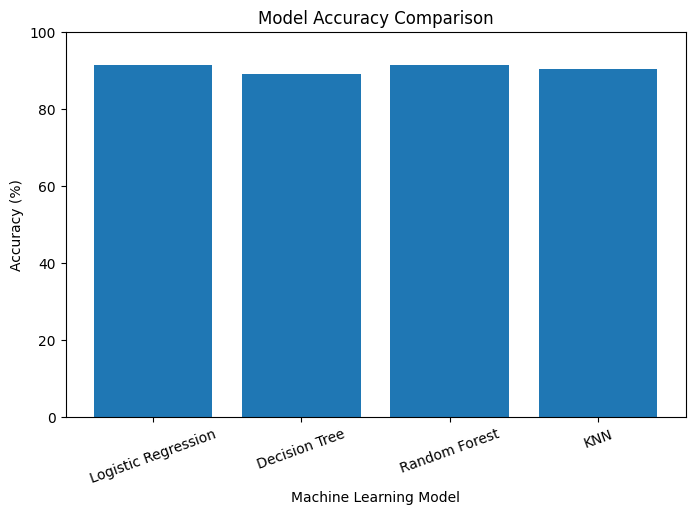

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [42]:
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

In [43]:
performance = []

for model_name, predictions in model_predictions.items():
    performance.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        )
    })

performance_df = pd.DataFrame(performance)

performance_df = performance_df.round(4)

display(performance_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.915,0.9136,0.915,0.9140
1,Decision Tree,0.890,0.8869,0.890,0.8874
2,Random Forest,0.915,0.9136,0.915,0.9140
3,KNN,0.905,0.9028,0.905,0.9032


In [44]:
best_model_name = performance_df.loc[
    performance_df["F1-Score"].idxmax(), "Model"
]

best_f1 = performance_df["F1-Score"].max()

print("Best Model based on F1-Score:", best_model_name)
print("Best F1-Score:", best_f1)

Best Model based on F1-Score: Logistic Regression
Best F1-Score: 0.914


In [45]:
performance_df.to_csv("model_comparison.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [46]:
best_predictions = model_predictions[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [47]:
from sklearn.metrics import classification_report

print("Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    best_predictions,
    zero_division=0
))

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        48
           1       0.94      0.95      0.94       152

    accuracy                           0.92       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.91      0.92      0.91       200



In [48]:
print("Loan Status Mapping:")
print(label_encoders["Loan_Status"].classes_)

Loan Status Mapping:
['N' 'Y']


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 38  10]
 [  7 145]]


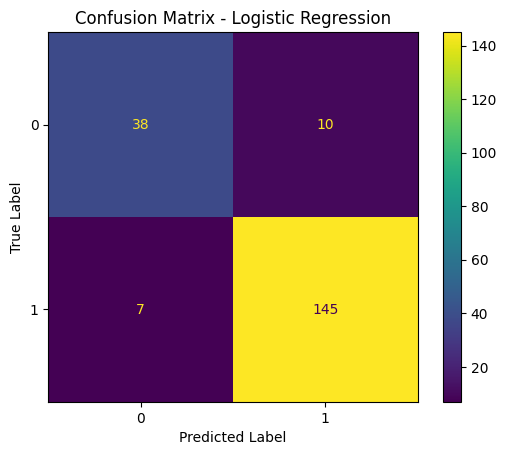

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [51]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

cm_df.to_csv("confusion_matrix.csv")

print("Confusion matrix saved successfully!")

,Predicted 0,Predicted 1
Actual 0,38,10
Actual 1,7,145


Confusion matrix saved successfully!


In [52]:
# Select the best model based on F1-Score

best_model_name = performance_df.loc[
    performance_df["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [53]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "KNN": knn_model
}

best_model = models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Logistic Regression


In [54]:
import joblib

In [55]:
joblib.dump(best_model, "best_loan_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [56]:
joblib.dump(scaler, "loan_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [57]:
performance_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [58]:
loaded_model = joblib.load("best_loan_model.pkl")

print("Saved model loaded successfully!")
print("Model type:", type(loaded_model))

Saved model loaded successfully!
Model type: <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [59]:
test_predictions = loaded_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Loaded Model Accuracy:", round(test_accuracy * 100, 2), "%")

Loaded Model Accuracy: 91.5 %
